# Chapter 2 — Sampling, Aliasing & Quantization

### Companion notebook · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/ch02_sampling_aliasing.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/ch02_sampling_aliasing.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=ch02_sampling_aliasing.ipynb)

> **Motivating question.** How does a continuous voltage become discrete numbers without lying about the truth?

## What this notebook demonstrates

- Nyquist–Shannon sampling theorem and the Nyquist frequency
- Aliasing and why it is irreversible
- Quantization SNR ≈ 6.02·N + 1.76 dB and crest-factor headroom
- Anti-alias filtering and the guard band
- Spatial / imaging sampling: moiré and Radon (CT) undersampling

## What you'll do

You'll sample a tone below and above the Nyquist rate to watch aliasing appear (and see why it can't be undone), check quantization SNR against the 6.02·N + 1.76 dB rule, and explore spatial undersampling (moiré, CT streaks).

## Runs in

| Platform | Status |
|---|---|
| **View (static)** | view only — outputs are pre-rendered |
| **Google Colab** | full, recommended |
| **JupyterLite** | full (synthetic data, NumPy/SciPy/sklearn only) |

**Data:** synthetic & reproducible (`SEED = 0`).  
**Runtime:** CPU, a few minutes.  
*All numbers below are illustrative and reproducible — not clinical benchmarks.*

In [1]:
%matplotlib inline
import sys, os, subprocess

# --- get the shared modules (bookstyle, biosignals, and the bsp package) ---
# Local repo checkout: they sit in ../src (package) and ../src/bsp (modules).
# Colab / JupyterLite: clone the repo once.
for c in ("src", "../src", "src/bsp", "../src/bsp"):
    if os.path.isdir(c):
        sys.path.insert(0, os.path.abspath(c))
try:
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup
except Exception:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "pywavelets", "scikit-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    for c in ("_bsp_repo/src", "_bsp_repo/src/bsp"):
        sys.path.insert(0, os.path.abspath(c))
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup

import numpy as np
import matplotlib.pyplot as plt
from bsp.loaders import setup
SEED = 0
rng = setup(SEED)     # fixes the seed; all synthetic data below is reproducible


environment : local
seed        : 0  (all synthetic data is reproducible)


## Setup: imports and shared helpers

These are the same building blocks the book's figures use; read them once, then reuse.

In [2]:
import numpy as np
from scipy import signal as sig

CH = 2


def _quantize(x, nbits, vmin=-1.0, vmax=1.0):
    # Mid-rise quantizer: round to the nearest level and reconstruct at that
    # level's cell *centre* (vmin+(xi+0.5)*q), so 0 is never an exact output
    # code. This introduces only a negligible bias (measured SNR sits within
    # ~0.3 dB of the theoretical 6.02N+1.76 dB, not several dB below it).
    levels = 2 ** nbits
    q = (vmax - vmin) / levels
    xi = np.round((x - vmin) / q - 0.5)      # cell index; centres sit at vmin+(xi+0.5)q
    xi = np.clip(xi, 0, levels - 1)
    return vmin + (xi + 0.5) * q

## 2.1  aliasing

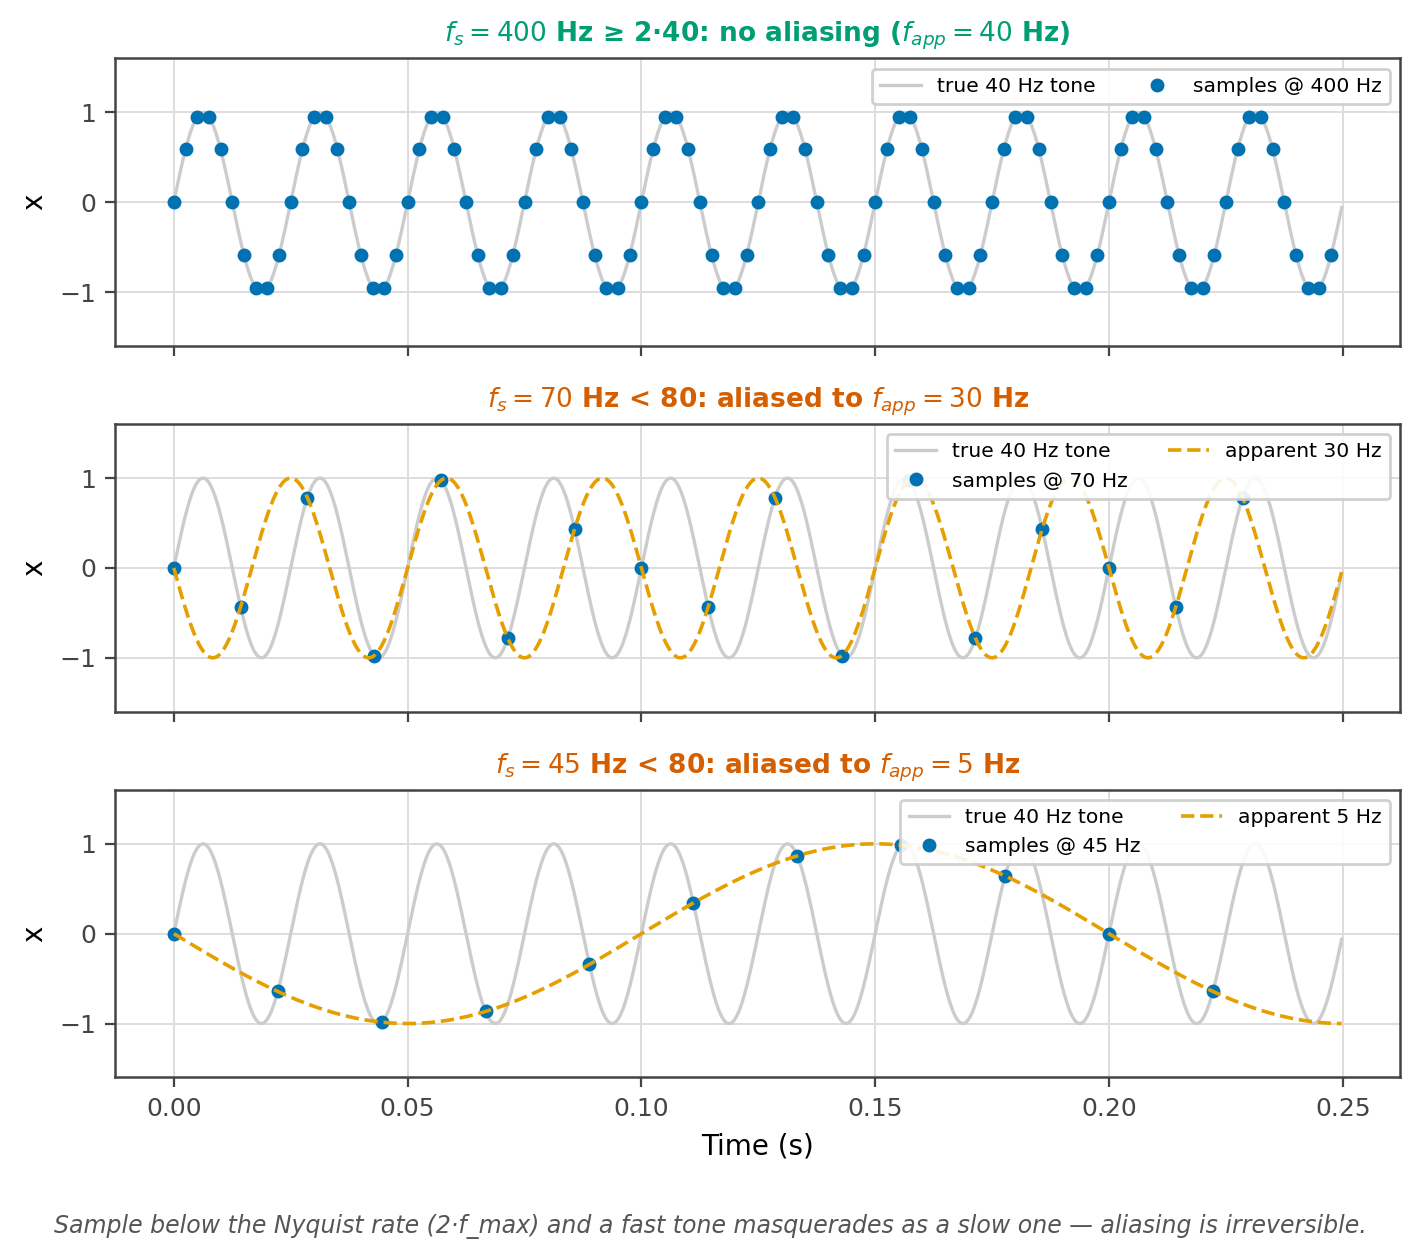

In [3]:
f0 = 40.0            # true tone frequency (Hz)
dur = 0.25
fs_hi = 4000.0       # "continuous" reference
t_hi = np.arange(int(dur * fs_hi)) / fs_hi
x_hi = np.sin(2 * np.pi * f0 * t_hi)

fs_list = [400.0, 70.0, 45.0]   # falling sample rates
fig, ax = bs.newfig(w=7.2, h=6.0, nrows=3, ncols=1, sharex=True)
for a, fs in zip(ax, fs_list):
    a.plot(t_hi, x_hi, color=bs.C["lightgrey"], lw=1.2,
           label="true 40 Hz tone")
    n = np.arange(int(dur * fs))
    ts = n / fs
    xs = np.sin(2 * np.pi * f0 * ts)
    a.plot(ts, xs, "o", color=bs.C["blue"], ms=4, label=f"samples @ {fs:g} Hz")
    # apparent (aliased) frequency -- signed fold, since the alias can land
    # with either sign of phase; using the unsigned magnitude here would
    # plot a curve that does not pass through the actual sample points.
    f_signed = f0 - fs * round(f0 / fs)
    f_alias = abs(f_signed)
    if fs >= 2 * f0:
        note = f"$f_s={fs:g}$ Hz ≥ 2·40: no aliasing ($f_{{app}}=40$ Hz)"
        col = bs.C["green"]
    else:
        note = f"$f_s={fs:g}$ Hz < 80: aliased to $f_{{app}}={f_alias:g}$ Hz"
        col = bs.C["red"]
        # draw the aliased low-freq sinusoid the samples imply
        x_al = np.sin(2 * np.pi * f_signed * t_hi)
        a.plot(t_hi, x_al, "--", color=bs.C["orange"], lw=1.3,
               label=f"apparent {f_alias:g} Hz")
    a.set_title(note, color=col, fontsize=9.5)
    a.set_ylabel("x")
    a.set_ylim(-1.6, 1.6)
    a.legend(loc="upper right", ncol=2, fontsize=7.3)
ax[-1].set_xlabel("Time (s)")
bs.takeaway(fig, "Sample below the Nyquist rate (2·f_max) and a fast tone "
                 "masquerades as a slow one — aliasing is irreversible.")
plt.tight_layout()
plt.show()

## 2.2  quantization

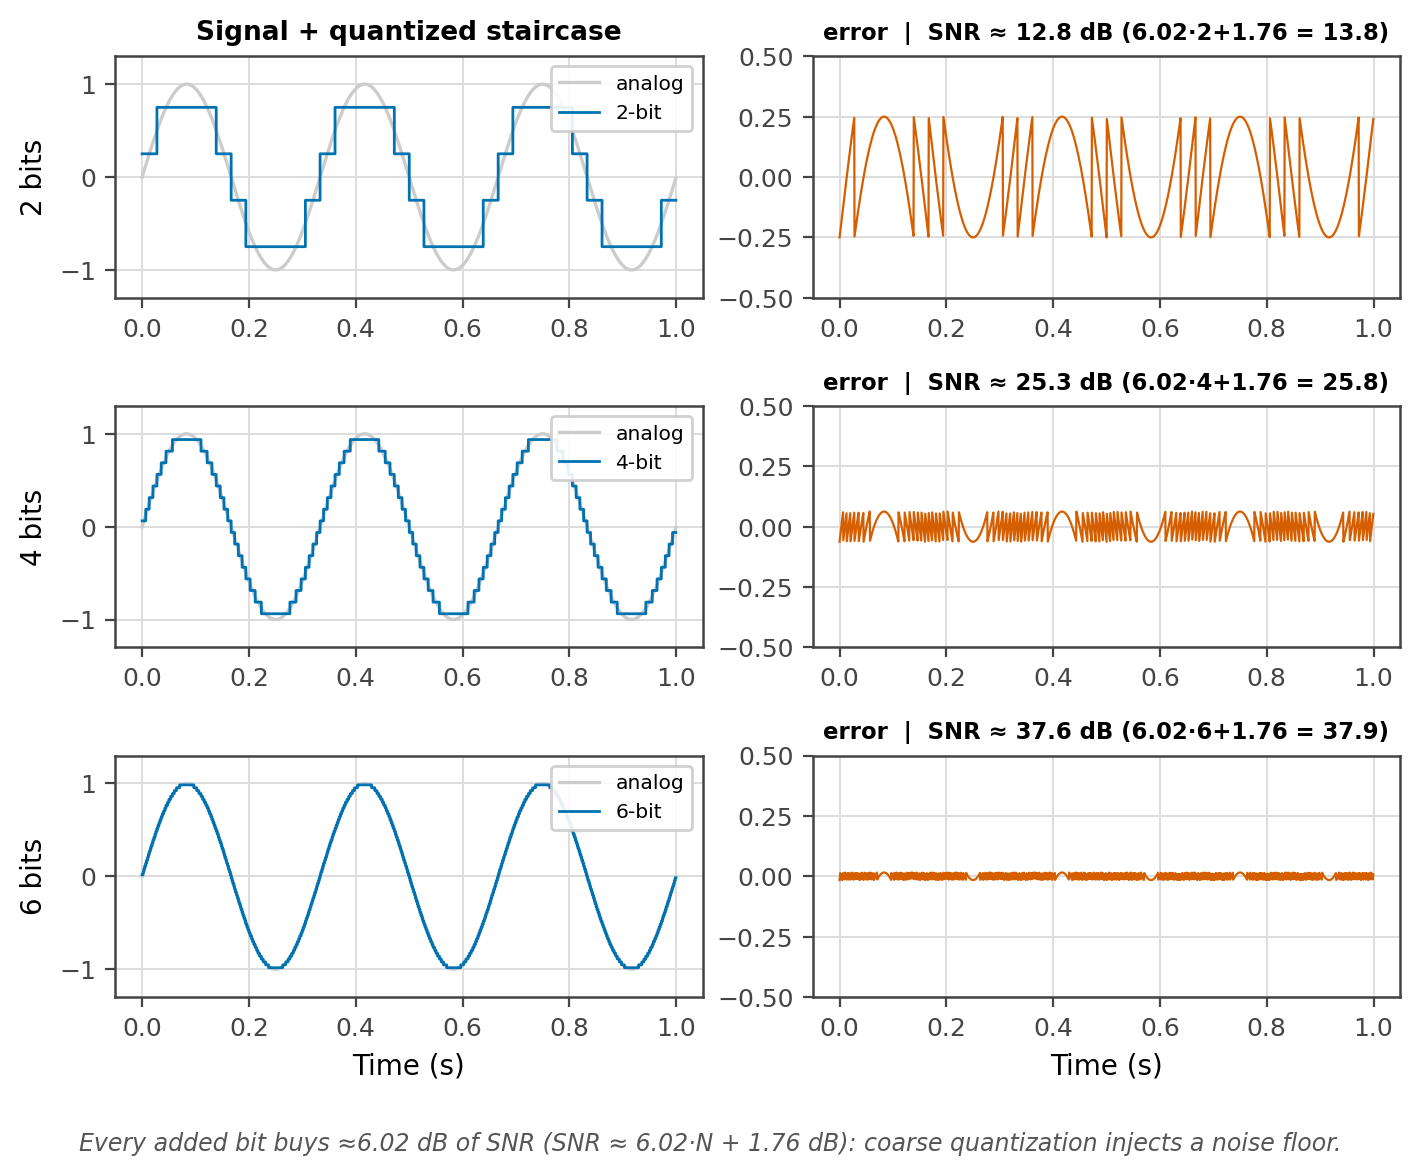

In [4]:
fs = 2000.0
t = np.arange(int(1.0 * fs)) / fs
x = np.sin(2 * np.pi * 3 * t)
fig, ax = bs.newfig(w=7.2, h=5.6, nrows=3, ncols=2)
for i, nb in enumerate([2, 4, 6]):
    xq = _quantize(x, nb)
    err = x - xq
    snr_theory = 6.02 * nb + 1.76
    snr_meas = 10 * np.log10(np.mean(x ** 2) / np.mean(err ** 2))
    # left: signal vs staircase
    ax[i, 0].plot(t, x, color=bs.C["lightgrey"], lw=1.2, label="analog")
    ax[i, 0].step(t, xq, where="mid", color=bs.C["blue"], lw=1.0,
                  label=f"{nb}-bit")
    ax[i, 0].set_ylabel(f"{nb} bits")
    ax[i, 0].set_ylim(-1.3, 1.3)
    ax[i, 0].legend(loc="upper right", fontsize=7.3)
    # right: quantization error
    ax[i, 1].plot(t, err, color=bs.C["red"], lw=0.8)
    ax[i, 1].set_ylim(-0.5, 0.5)
    ax[i, 1].set_title(f"error  |  SNR ≈ {snr_meas:.1f} dB "
                       f"(6.02·{nb}+1.76 = {snr_theory:.1f})",
                       fontsize=8.2)
ax[0, 0].set_title("Signal + quantized staircase", fontsize=9.5)
ax[2, 0].set_xlabel("Time (s)")
ax[2, 1].set_xlabel("Time (s)")
bs.takeaway(fig, "Every added bit buys ≈6.02 dB of SNR (SNR ≈ 6.02·N + 1.76 dB): "
                 "coarse quantization injects a noise floor.")
plt.tight_layout()
plt.show()

## 2.3  motion artifact

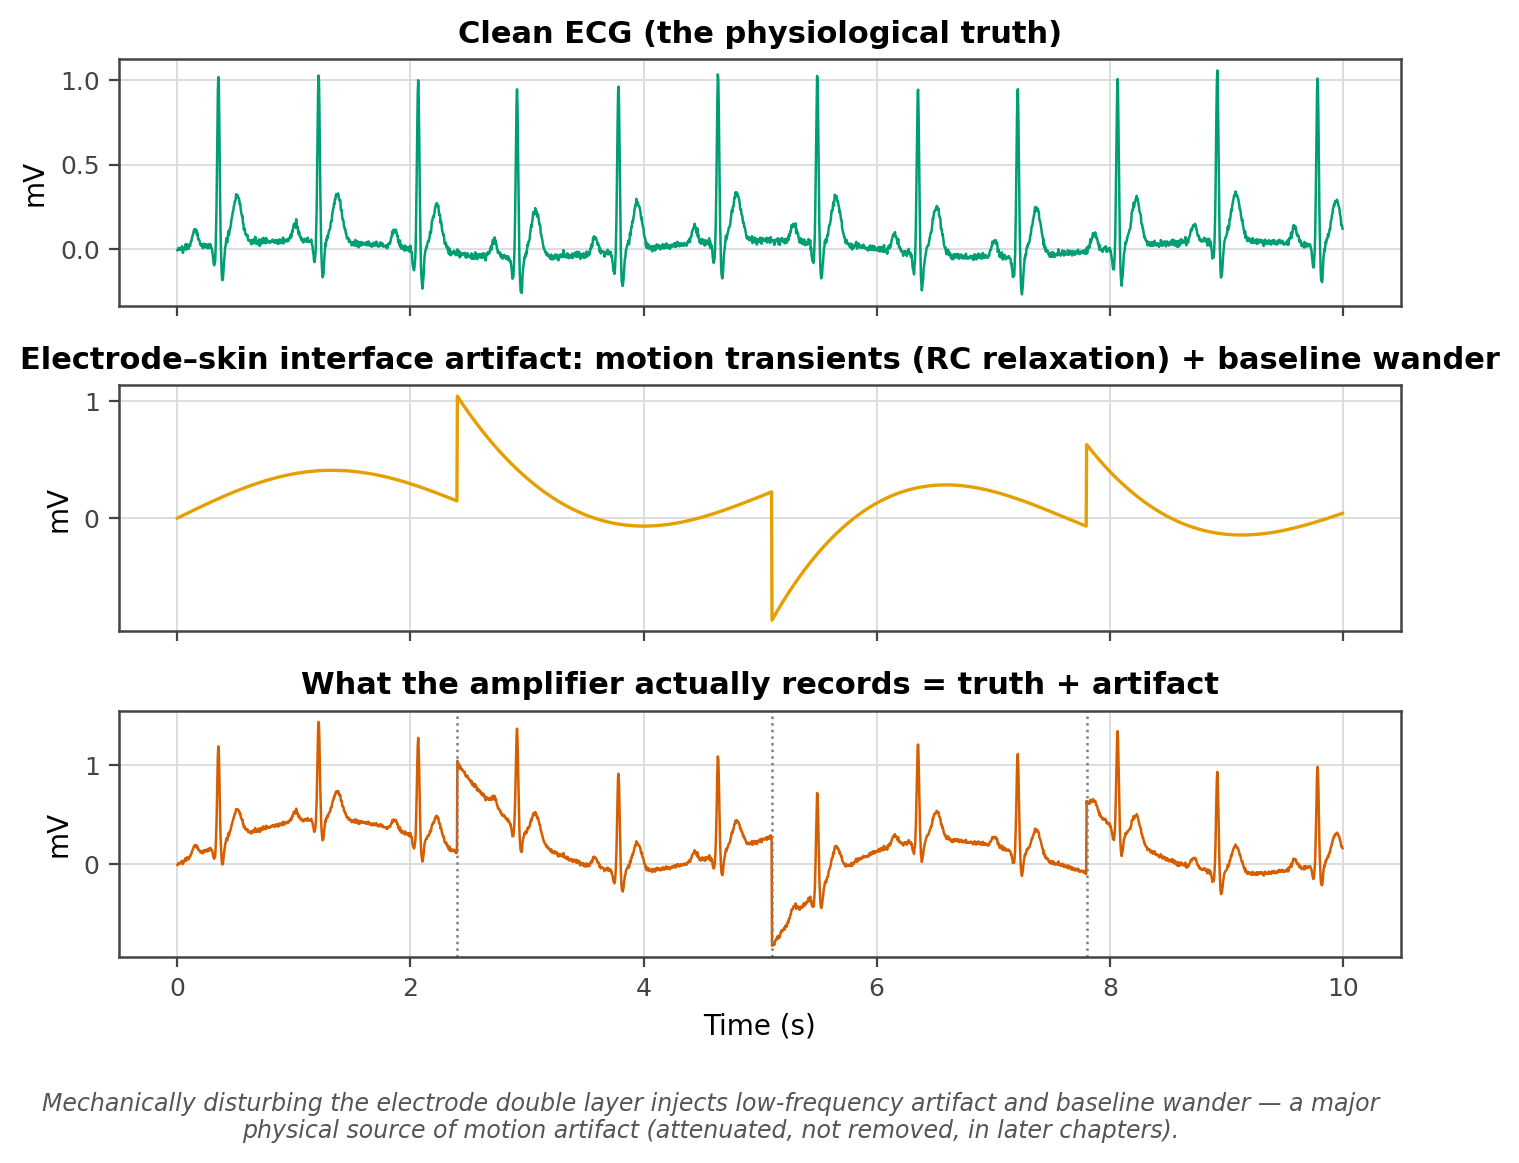

In [5]:
# clean ECG
t, x = bio.ecg(duration=10.0, fs=256, hr=70, noise=0.01)
fs = 256.0
r = bio.rng(21)
# model the electrode-skin interface disturbance as low-frequency transients:
# motion events kick the double-layer, producing exponentially-relaxing
# offsets (an RC discharge) + slow baseline wander.
art = np.zeros_like(t)
for tc, amp in [(2.4, 0.9), (5.1, -1.1), (7.8, 0.7)]:
    tau = 0.8
    step = np.where(t >= tc, np.exp(-(t - tc) / tau), 0.0)
    art += amp * step
# slow baseline wander (respiration-coupled + electrode drift)
art += 0.35 * np.sin(2 * np.pi * 0.2 * t) + 0.15 * np.sin(2 * np.pi * 0.05 * t)
x_meas = x + art

fig, ax = bs.newfig(w=7.2, h=5.4, nrows=3, ncols=1, sharex=True)
ax[0].plot(t, x, color=bs.C["green"], lw=0.9)
ax[0].set_title("Clean ECG (the physiological truth)")
ax[0].set_ylabel("mV")
ax[1].plot(t, art, color=bs.C["orange"], lw=1.2)
ax[1].set_title("Electrode–skin interface artifact: motion transients "
                "(RC relaxation) + baseline wander")
ax[1].set_ylabel("mV")
ax[2].plot(t, x_meas, color=bs.C["red"], lw=0.9)
ax[2].set_title("What the amplifier actually records = truth + artifact")
ax[2].set_ylabel("mV")
ax[2].set_xlabel("Time (s)")
for tc in [2.4, 5.1, 7.8]:
    ax[2].axvline(tc, color=bs.C["grey"], ls=":", lw=0.9)
bs.takeaway(fig, "Mechanically disturbing the electrode double layer injects "
                 "low-frequency artifact and baseline wander — a major physical "
                 "source of motion artifact (attenuated, not removed, in later chapters).")
plt.tight_layout()
plt.show()

## 2.4  spatial

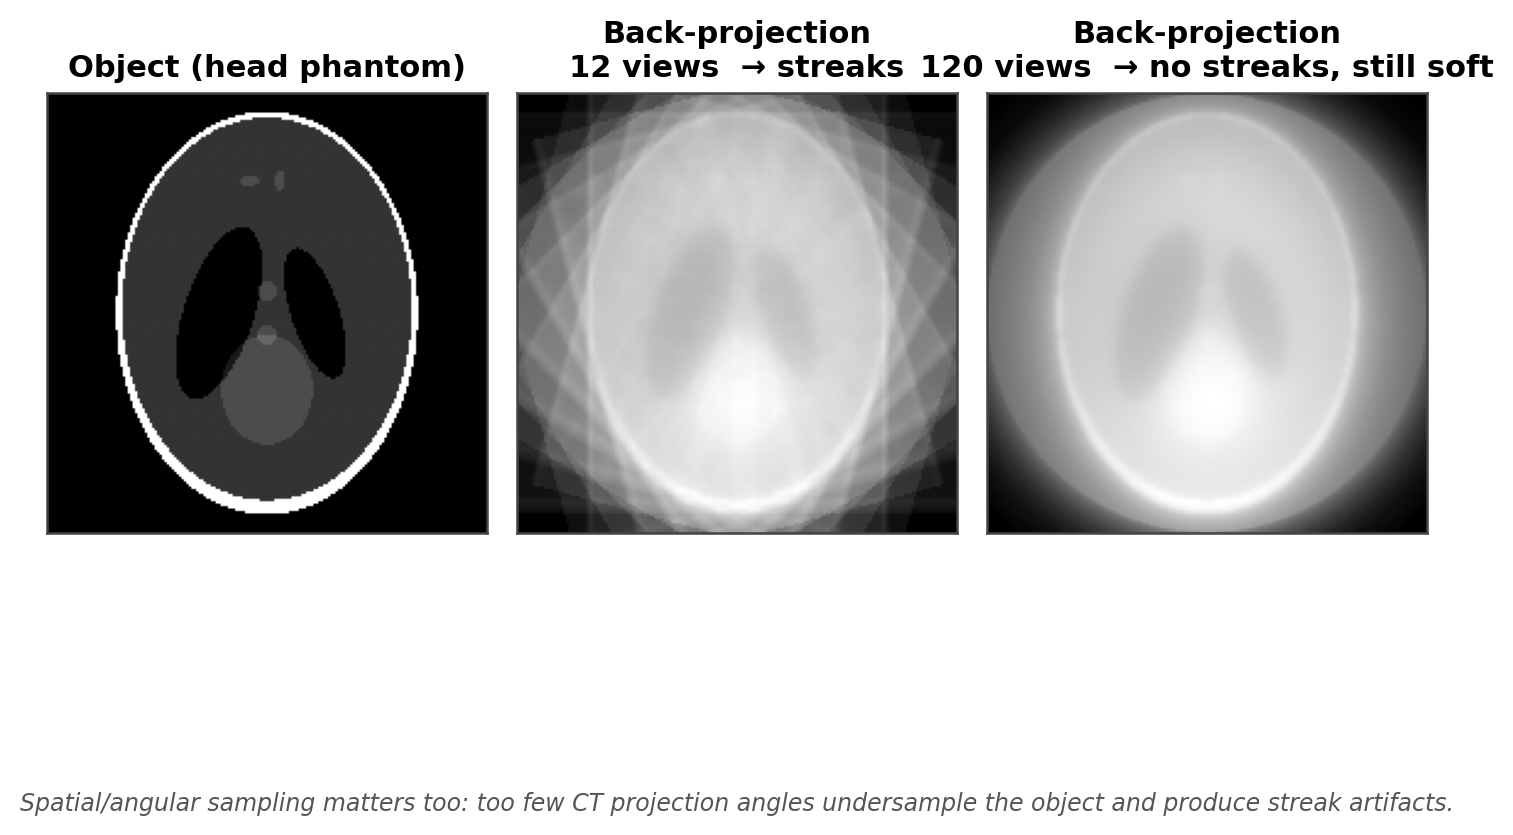

In [6]:
img = bio.head_phantom(size=180)

# Reconstruction lives in bsp.biosignals.ct_backproject so the Ch2 exploration
# exercise (reconstruct at 8/32/256 views, RMSE vs a reference) runs the same
# code this figure does.
fig, ax = bs.newfig(w=7.2, h=4.6, nrows=1, ncols=3)
ax[0].imshow(img, cmap="gray")
ax[0].set_title("Object (head phantom)")

for a, nv in zip(ax[1:], [12, 120]):
    recon = bio.ct_backproject(img, nv)
    a.imshow(recon, cmap="gray")
    a.set_title(f"Back-projection\n{nv} views"
                + ("  → streaks" if nv == 12 else "  → no streaks, still soft"))
for a in ax:
    a.set_xticks([]); a.set_yticks([]); a.grid(False)
bs.takeaway(fig, "Spatial/angular sampling matters too: too few CT projection "
                 "angles undersample the object and produce streak artifacts.")
plt.tight_layout()
plt.show()

## Expected outputs (reproducibility)

Because `SEED = 0`, re-running reproduces the figures above and the numbers below *exactly* — the cell below **asserts** them with `expect_close`, so a broken environment is flagged rather than failing silently.

In [7]:
from bsp.metrics import (alias_frequency, quantization_snr_db, sqrtN_gain_db,
                         snr_db, cohens_kappa, macro_f1)
from bsp.notebook_checks import expect_close, expected_output_table
from IPython.display import Markdown, display
_rows = []
_rows.append(expect_close('apparent alias frequency, 40 Hz @ 70 Hz (Hz)', alias_frequency(40, 70), 30.0, 0.1, 'abs'))
_rows.append(expect_close('apparent alias frequency, 40 Hz @ 45 Hz (Hz)', alias_frequency(40, 45), 5.0, 0.1, 'abs'))
_rows.append(expect_close('quantization SNR, 6-bit (dB)', quantization_snr_db(6), 37.88, 0.1, 'abs'))
display(Markdown(expected_output_table(_rows)))

[PASS] apparent alias frequency, 40 Hz @ 70 Hz (Hz): got 30, expected 30 (abs)
[PASS] apparent alias frequency, 40 Hz @ 45 Hz (Hz): got 5, expected 5 (abs)
[PASS] quantization SNR, 6-bit (dB): got 37.88, expected 37.88 (abs)


| Quantity | Got | Expected | Status |
|---|---:|---:|:--:|
| apparent alias frequency, 40 Hz @ 70 Hz (Hz) | 30 | 30 | ✅ |
| apparent alias frequency, 40 Hz @ 45 Hz (Hz) | 5 | 5 | ✅ |
| quantization SNR, 6-bit (dB) | 37.88 | 37.88 | ✅ |

## MATLAB equivalent

The worked code here is Python-primary. The nearest MATLAB calls:

> `y = x(1:R:end)` to downsample; quantize with `round(x/q)*q`.

## Student tasks


For each task: **predict** the change first, **run** it, then **explain** the number you get. Use the workspace cell below (or duplicate a figure cell and edit it). Each task has a collapsible **hint** — commit your prediction *before* you open it.


**1.** Drop the sampling rate on a 40 Hz tone and predict the apparent (alias) frequency.

<details><summary>💡 Hint &amp; what you should see</summary>

alias = |f − k·fs| for the integer k giving the smallest positive value. At fs=70 → |40−70| = **30 Hz**; at fs=45 → |40−45| = **5 Hz**. The spectral peak moves exactly there.

</details>

**2.** Show that adding bits does NOT fix aliasing — only the sample rate and anti-alias filter do.

<details><summary>💡 Hint &amp; what you should see</summary>

Aliasing is fixed at sampling; more bits only lower quantization noise (the SNR ≈ 6.02N + 1.76 dB line), not the alias. The aliased peak **stays put** at any bit depth — only a higher fs or an anti-alias filter removes it.

</details>

In [8]:
# Your workspace — attempt the tasks above.
# Tip: copy a figure cell, change ONE parameter, predict, then re-run.


---
*Companion notebook for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic data; illustrative numbers. Generated from `figures_src/ch02_figures.py`.*